In [13]:
import pandas as pd
rawData = pd.read_csv('InterimReport/Urban_Air_Quality_and_Health_Impact.csv')

rawData.head()

# 修正：使用 rawData 而不是 data
X = rawData.drop('Health_Risk_Score', axis=1)
y = rawData['Health_Risk_Score']

## 資料分析與前處理

In [14]:
# 檢查資料基本資訊
print("資料形狀:", rawData.shape)
print("\n資料類型:")
print(rawData.dtypes)
print("\n缺失值統計:")
print(rawData.isnull().sum())
print("\n基本統計摘要:")
print(rawData.describe())

資料形狀: (1000, 46)

資料類型:
datetime              object
datetimeEpoch        float64
tempmax              float64
tempmin              float64
temp                 float64
feelslikemax         float64
feelslikemin         float64
feelslike            float64
dew                  float64
humidity             float64
precip               float64
precipprob           float64
precipcover          float64
preciptype            object
snow                 float64
snowdepth            float64
windgust             float64
windspeed            float64
winddir              float64
pressure             float64
cloudcover           float64
visibility           float64
solarradiation       float64
solarenergy          float64
uvindex              float64
severerisk           float64
sunrise               object
sunriseEpoch         float64
sunset                object
sunsetEpoch          float64
moonphase            float64
conditions            object
description           object
icon               

類別變數: ['datetime', 'preciptype', 'sunrise', 'sunset', 'conditions', 'description', 'icon', 'stations', 'source', 'City', 'Season', 'Day_of_Week']

datetime 的唯一值數量: 15
datetime
2024-09-14    74
2024-09-18    73
2024-09-08    72
2024-09-09    72
2024-09-07    67
Name: count, dtype: int64

preciptype 的唯一值數量: 1
preciptype
['rain']    378
Name: count, dtype: int64

sunrise 的唯一值數量: 148
sunrise
06:35:57    12
06:38:11    12
07:08:01    12
06:23:01    12
07:09:18    11
Name: count, dtype: int64

sunset 的唯一值數量: 145
sunset
19:00:52    18
19:43:25    16
18:48:38    14
19:28:36    12
19:02:33    12
Name: count, dtype: int64

conditions 的唯一值數量: 4
conditions
Clear                     569
Partially cloudy          363
Rain, Partially cloudy     55
Overcast                   13
Name: count, dtype: int64

description 的唯一值數量: 12
description
Clear conditions throughout the day.                      554
Partly cloudy throughout the day.                         289
Becoming cloudy in the afternoon.        

/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20296 (\N{CJK UNIFIED IDEOGRAPH-4F48}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


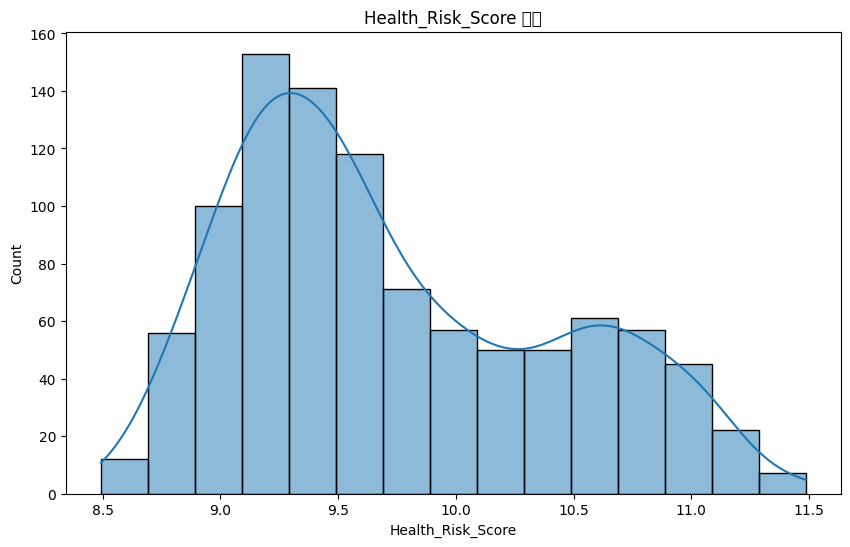

In [15]:
# 檢查類別變數
categorical_cols = rawData.select_dtypes(include=['object']).columns
print("類別變數:", categorical_cols.tolist())
for col in categorical_cols:
    print(f"\n{col} 的唯一值數量: {rawData[col].nunique()}")
    print(rawData[col].value_counts().head())

# 檢查數值變數分佈
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = rawData.select_dtypes(include=['float64', 'int64']).columns
print("\n數值變數:", numerical_cols.tolist())

# 繪製目標變數的分佈
plt.figure(figsize=(10, 6))
sns.histplot(rawData['Health_Risk_Score'], kde=True)
plt.title('Health_Risk_Score 分佈')
plt.show()

/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35722 (\N{CJK UNIFIED IDEOGRAPH-8B8A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packa

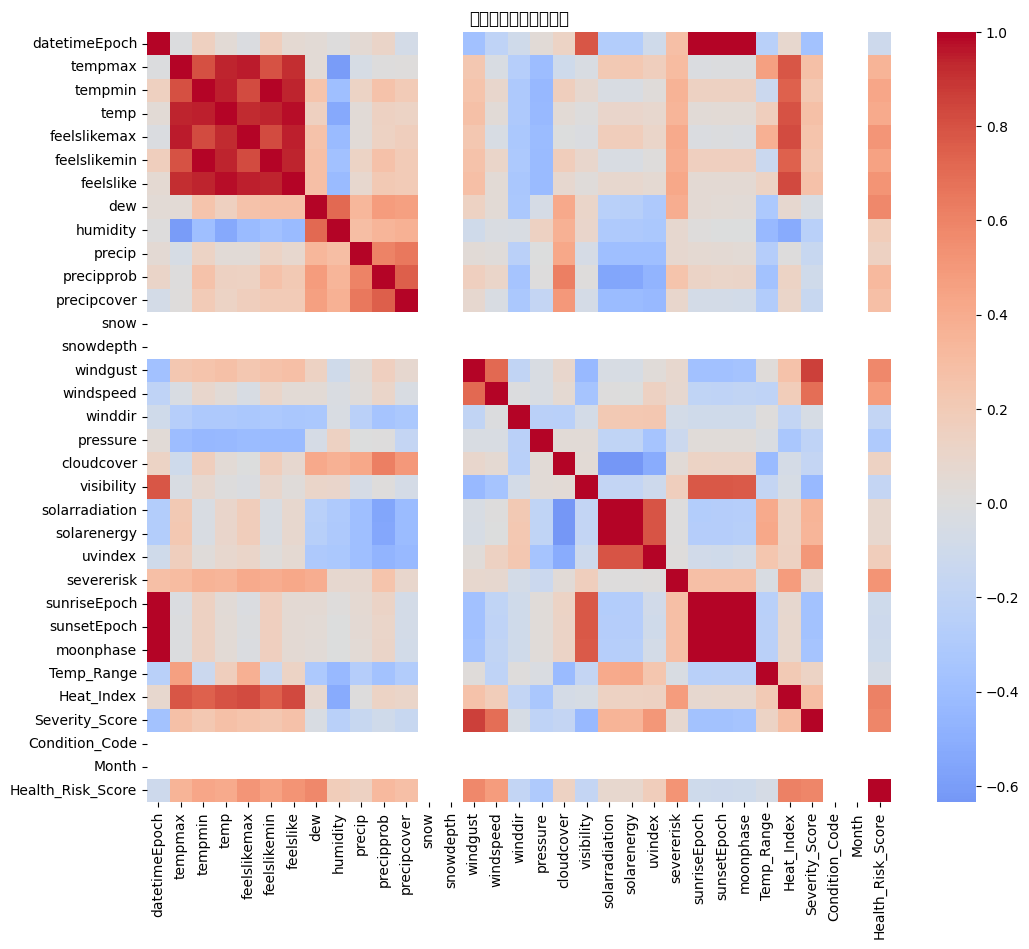

與 Health_Risk_Score 最相關的變數:
Health_Risk_Score    1.000000
Heat_Index           0.610722
Severity_Score       0.585555
windgust             0.583670
dew                  0.581391
severerisk           0.524030
feelslike            0.522430
feelslikemax         0.518574
windspeed            0.487805
feelslikemin         0.454905
Name: Health_Risk_Score, dtype: float64


In [16]:
# 相關性分析
# 選擇數值變數進行相關性分析
numerical_data = rawData.select_dtypes(include=['float64', 'int64'])

# 計算相關性矩陣
correlation_matrix = numerical_data.corr()

# 繪製熱力圖
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('數值變數相關性熱力圖')
plt.show()

# 與目標變數最相關的變數
target_corr = correlation_matrix['Health_Risk_Score'].abs().sort_values(ascending=False)
print("與 Health_Risk_Score 最相關的變數:")
print(target_corr.head(10))

In [17]:
# 前處理

# 1. 處理缺失值
print("處理前缺失值:")
print(rawData.isnull().sum())

# 對於數值變數，使用中位數填補
numerical_cols = rawData.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    if rawData[col].isnull().sum() > 0:
        rawData[col].fillna(rawData[col].median(), inplace=True)

# 對於類別變數，使用眾數填補
categorical_cols = rawData.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if rawData[col].isnull().sum() > 0:
        rawData[col].fillna(rawData[col].mode()[0], inplace=True)

print("\n處理後缺失值:")
print(rawData.isnull().sum())

# 2. 編碼類別變數
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    rawData[col] = le.fit_transform(rawData[col])
    label_encoders[col] = le

print("\n類別變數編碼完成")

# 3. 標準化數值變數
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rawData[numerical_cols] = scaler.fit_transform(rawData[numerical_cols])

print("數值變數標準化完成")

# 4. 定義特徵和目標變數
X = rawData.drop('Health_Risk_Score', axis=1)
y = rawData['Health_Risk_Score']

print(f"\n特徵矩陣形狀: {X.shape}")
print(f"目標變數形狀: {y.shape}")

# 5. 分割訓練和測試集
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=100
)

print(f"\n訓練集形狀: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"測試集形狀: X_test={X_test.shape}, y_test={y_test.shape}")

處理前缺失值:
datetime               0
datetimeEpoch          0
tempmax                0
tempmin                0
temp                   0
feelslikemax           0
feelslikemin           0
feelslike              0
dew                    0
humidity               0
precip                 0
precipprob             0
precipcover            0
preciptype           622
snow                   0
snowdepth             71
windgust               0
windspeed              0
winddir                0
pressure               0
cloudcover             0
visibility             0
solarradiation         0
solarenergy            0
uvindex                0
severerisk             0
sunrise                0
sunriseEpoch           0
sunset                 0
sunsetEpoch            0
moonphase              0
conditions             0
description            0
icon                   0
stations             933
source                 0
City                   0
Temp_Range             0
Heat_Index             0
Severity_Score   

/var/folders/b_/7l5pfh497cb4pvygfn49ll_40000gn/T/ipykernel_9411/2230916262.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  rawData[col].fillna(rawData[col].median(), inplace=True)
/var/folders/b_/7l5pfh497cb4pvygfn49ll_40000gn/T/ipykernel_9411/2230916262.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

In [18]:
# 前處理完成摘要
print("=== 資料前處理完成 ===")
print(f"原始資料形狀: {rawData.shape}")
print(f"特徵數量: {X.shape[1]}")
print(f"訓練樣本數: {X_train.shape[0]}")
print(f"測試樣本數: {X_test.shape[0]}")
print(f"目標變數類型: 連續變數 (回歸問題)")

# 檢查前處理後的資料
print("\n前處理後的資料摘要:")
print(X_train.describe())

=== 資料前處理完成 ===
原始資料形狀: (1000, 46)
特徵數量: 45
訓練樣本數: 800
測試樣本數: 200
目標變數類型: 連續變數 (回歸問題)

前處理後的資料摘要:
         datetime  datetimeEpoch     tempmax     tempmin        temp  \
count  800.000000     800.000000  800.000000  800.000000  800.000000   
mean     6.895000      -0.005716   -0.011156   -0.014444   -0.012388   
std      4.353178       1.000850    0.985374    0.992548    0.986847   
min      0.000000      -1.763224   -2.351018   -2.306226   -2.359284   
25%      3.000000      -0.904616   -0.689295   -0.716410   -0.797447   
50%      7.000000       0.003351   -0.089478   -0.134177   -0.116029   
75%     11.000000       0.845426    0.574842    0.802445    0.640742   
max     14.000000       1.786819    2.383583    2.714791    2.722702   

       feelslikemax  feelslikemin   feelslike         dew    humidity  ...  \
count    800.000000    800.000000  800.000000  800.000000  800.000000  ...   
mean      -0.017848     -0.016888   -0.015478   -0.014996   -0.013554  ...   
std        0.983977

In [19]:
# KMeans 演算法
from sklearn import cluster
import numpy as np

kmeans_fit = cluster.KMeans(n_clusters=3, random_state=100).fit(X_train)

cluster_labels = kmeans_fit.labels_
print(f"分群結果：{cluster_labels}")
print("=================================")
print(f"各群樣本數：")
for label, count in zip(*np.unique(cluster_labels, return_counts=True)):
    print(f"群 {label}: {count} 筆")
print("=================================")
print(f"群中心點：\n{kmeans_fit.cluster_centers_}")

分群結果：[1 1 2 1 1 1 0 2 1 1 1 1 1 1 1 1 1 1 2 1 1 2 2 0 0 0 2 1 0 1 0 1 2 1 1 1 0
 0 0 2 1 2 2 1 1 1 2 0 1 1 2 2 2 1 1 1 1 1 1 0 2 1 1 1 1 2 1 2 2 0 1 0 1 1
 1 2 2 1 0 0 2 1 2 1 0 0 1 1 1 1 0 1 2 1 1 0 1 1 1 1 0 2 2 1 1 0 0 0 2 0 1
 1 1 0 2 2 0 1 1 1 2 2 2 1 1 1 1 1 1 1 1 2 2 1 2 1 1 2 1 2 1 0 1 2 2 1 1 1
 1 2 2 0 2 0 1 0 1 1 1 1 1 1 1 2 1 1 2 0 1 2 0 1 1 1 2 1 1 1 2 1 1 1 0 1 1
 1 1 2 1 2 1 1 2 1 1 1 1 2 1 2 1 2 0 2 0 1 0 1 1 1 0 1 1 1 1 2 1 1 2 0 1 1
 0 2 0 2 2 2 0 1 1 1 2 2 2 2 2 1 0 2 0 1 2 0 1 1 2 0 2 2 1 2 1 1 1 1 2 0 1
 1 0 2 1 2 1 1 1 1 0 0 1 2 2 2 1 1 2 2 0 0 1 0 2 1 1 0 0 0 1 1 0 1 1 0 1 1
 1 2 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1 0 1 0 2 1 1 2 1 1 1 2 2 1 1 1 1
 2 1 1 1 2 2 1 1 1 1 1 1 1 1 0 2 2 1 1 0 0 1 1 0 1 2 1 0 2 2 0 2 1 0 0 1 1
 2 2 0 1 1 1 0 0 2 0 2 2 1 1 2 1 0 1 1 2 1 1 1 2 2 0 2 1 0 1 1 1 2 2 1 2 0
 1 1 0 1 1 0 1 1 2 1 0 2 1 1 2 2 2 1 1 1 1 1 1 1 1 1 1 0 1 2 2 0 2 0 1 0 1
 2 2 2 2 1 0 1 0 2 0 0 1 1 0 1 1 1 2 2 2 1 1 1 2 1 2 0 1 1 1 0 1 0 2 1 1 1
 1 1 1 1 1 2 2 1 0 1

## 4.分群演算法的績效
使用Silhouette 係數


## 1. KMeans 分群演算法

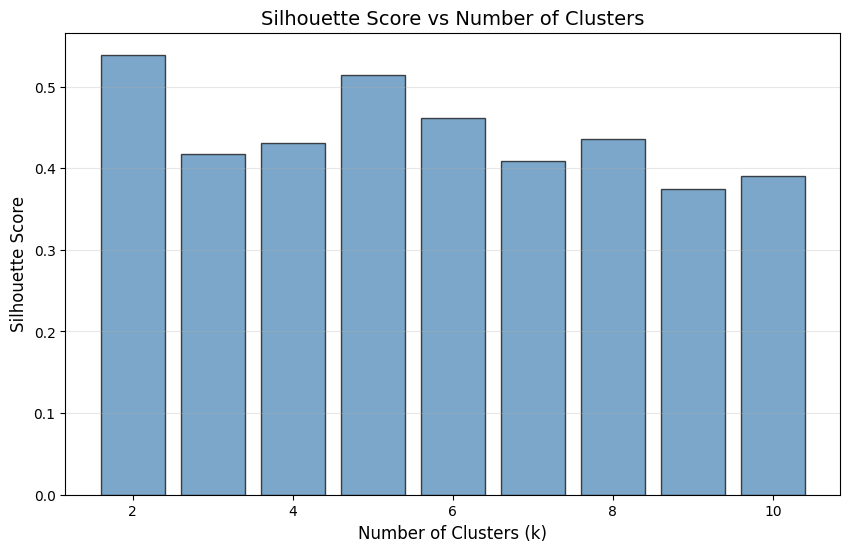

各群數的 Silhouette 係數:
k=2: 0.5390
k=3: 0.4173
k=4: 0.4310
k=5: 0.5142
k=6: 0.4611
k=7: 0.4090
k=8: 0.4355
k=9: 0.3751
k=10: 0.3901

最佳群數: 2 (Silhouette Score: 0.5390)


In [20]:
from sklearn import metrics
import matplotlib.pyplot as plt

# 評估 KMeans 的績效 - 使用 Silhouette 係數找最佳群數
silhouette_avgs = []
ks = range(2, 11)
for k in ks:
    kmeans_fit = cluster.KMeans(n_clusters=k, random_state=100).fit(X_train)
    cluster_labels = kmeans_fit.labels_
    silhouette_avg = metrics.silhouette_score(X_train, cluster_labels)
    silhouette_avgs.append(silhouette_avg)

# 繪製 Silhouette 係數圖
plt.figure(figsize=(10, 6))
plt.bar(ks, silhouette_avgs, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs Number of Clusters', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

print("各群數的 Silhouette 係數:")
for k, score in zip(ks, silhouette_avgs):
    print(f"k={k}: {score:.4f}")

# 找出最佳群數
best_k = ks[silhouette_avgs.index(max(silhouette_avgs))]
print(f"\n最佳群數: {best_k} (Silhouette Score: {max(silhouette_avgs):.4f})")

# Hierarchical clustering 演算法

分群結果：[0 0 1 0 0 0 2 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 2 2 2 1 0 2 0 2 0 1 0 0 0 2
 2 2 1 0 1 1 0 0 0 1 2 0 0 1 1 1 0 0 0 0 0 0 2 1 0 0 0 0 1 0 1 1 2 0 2 0 0
 0 1 1 0 2 2 1 0 1 0 2 2 0 0 0 0 2 0 1 0 0 2 0 0 0 0 2 1 1 0 0 2 2 2 1 2 0
 0 0 2 1 1 2 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 1 0 2 0 1 1 0 0 0
 0 1 1 2 1 2 0 2 0 0 0 0 0 0 0 1 0 0 1 2 0 1 2 0 0 0 1 0 0 0 1 0 0 0 2 0 0
 0 0 1 0 1 0 0 1 0 0 0 0 1 0 1 0 1 2 1 2 0 2 0 0 0 2 0 0 0 0 1 0 0 1 2 0 0
 2 1 2 1 1 1 2 0 0 0 1 1 1 1 1 0 2 1 2 0 1 2 0 0 1 2 1 1 0 1 0 0 0 0 1 2 0
 0 2 1 0 1 0 0 0 0 2 2 0 1 1 1 0 0 1 1 2 2 0 2 1 0 0 2 2 2 0 0 2 0 0 2 0 0
 0 1 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 0 0 2 0 2 0 2 1 0 0 1 0 0 0 1 1 0 0 0 0
 1 0 0 0 1 1 0 0 0 0 0 0 0 0 2 1 1 0 0 2 2 0 0 2 0 1 0 2 1 1 2 1 0 2 2 0 0
 1 1 2 0 0 0 2 2 1 2 1 1 0 0 1 0 2 0 0 1 0 0 0 1 1 2 1 0 2 0 0 0 1 1 0 1 2
 0 0 2 0 0 2 0 0 1 0 2 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 2 0 1 1 2 1 2 0 2 0
 1 1 1 1 0 2 0 2 1 2 2 0 0 2 0 0 0 1 1 1 0 0 0 1 0 1 2 0 0 0 2 0 2 1 0 0 0
 0 0 0 0 0 1 1 0 2 0

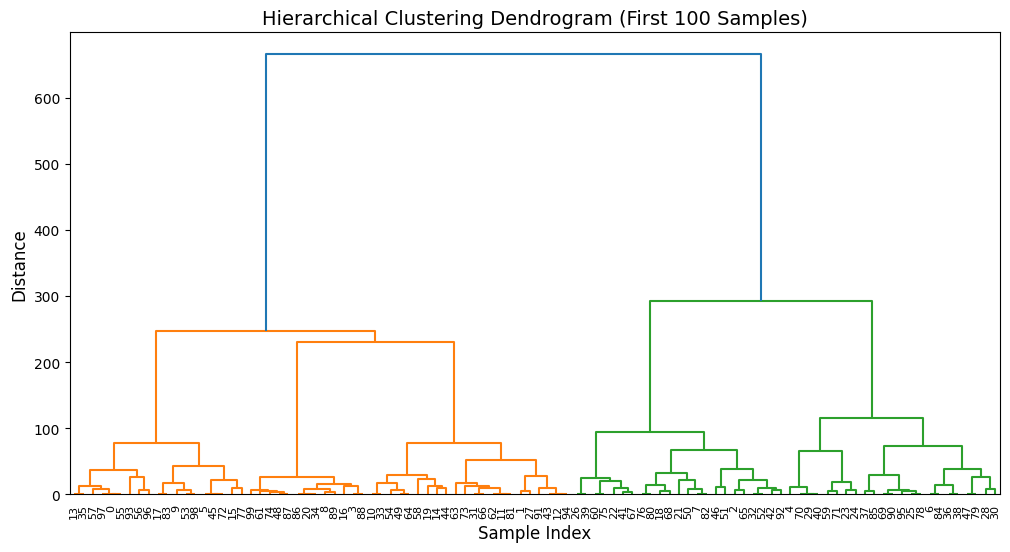

In [21]:
# Hierarchical Clustering 演算法
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np

# 建立階層式分群模型
hclust = cluster.AgglomerativeClustering(linkage='ward', n_clusters=3)
hclust.fit(X_train)
cluster_labels = hclust.labels_

print(f"分群結果：{cluster_labels}")
print("=================================")
print(f"各群樣本數：")
for label, count in zip(*np.unique(cluster_labels, return_counts=True)):
    print(f"群 {label}: {count} 筆")

# 計算 Silhouette 係數
silhouette_avg = metrics.silhouette_score(X_train, cluster_labels)
print(f"\nSilhouette 係數：{silhouette_avg:.4f}")

# 繪製樹狀圖（使用前 100 筆資料以避免圖表過於複雜）
plt.figure(figsize=(12, 6))
mergings = linkage(X_train[:100], method='ward')
dendrogram(mergings, leaf_rotation=90, leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram (First 100 Samples)', fontsize=14)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.show()

# DBSCAN 分群

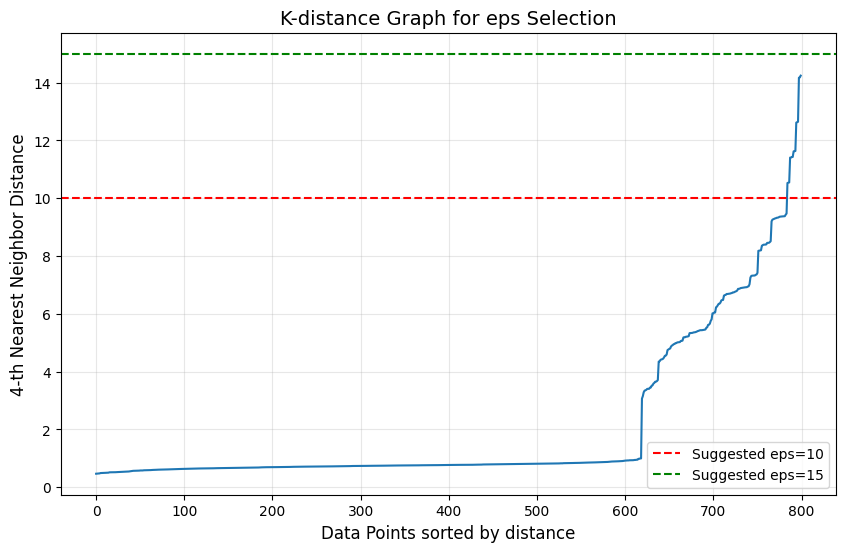

距離統計:
中位數: 0.77
75分位數: 0.92
90分位數: 6.70
95分位數: 8.40

建議 eps 值範圍: 0.92 ~ 8.40


In [25]:
# DBSCAN 參數調整 - 找出最佳 eps 值
from sklearn.neighbors import NearestNeighbors
import numpy as np

# 計算每個點到其最近鄰居的距離
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_train)
distances, indices = neighbors_fit.kneighbors(X_train)

# 取每個點到第 k 個最近鄰居的距離（k=4，因為第0個是自己）
distances = np.sort(distances[:, 4], axis=0)

# 繪製 k-distance 圖以找出最佳 eps
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Data Points sorted by distance', fontsize=12)
plt.ylabel('4-th Nearest Neighbor Distance', fontsize=12)
plt.title('K-distance Graph for eps Selection', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=10, color='r', linestyle='--', label='Suggested eps=10')
plt.axhline(y=15, color='g', linestyle='--', label='Suggested eps=15')
plt.legend()
plt.show()

# 輸出統計資訊
print(f"距離統計:")
print(f"中位數: {np.median(distances):.2f}")
print(f"75分位數: {np.percentile(distances, 75):.2f}")
print(f"90分位數: {np.percentile(distances, 90):.2f}")
print(f"95分位數: {np.percentile(distances, 95):.2f}")
print(f"\n建議 eps 值範圍: {np.percentile(distances, 75):.2f} ~ {np.percentile(distances, 95):.2f}")

=== 測試不同 eps 值的分群結果 ===

eps=10: 28 群, 16 個噪音點
eps=12: 10 群, 6 個噪音點
eps=14: 8 群, 3 個噪音點
eps=16: 5 群, 0 個噪音點
eps=18: 5 群, 0 個噪音點
eps=20: 3 群, 0 個噪音點

=== 最終 DBSCAN 分群結果 (eps=14, min_samples=5) ===
分群結果：[ 0  0  1  2  0  0  3  4  2  0  0  0  0  0  0  0  2  0  1  0  2  4  5  6
  6  3  5  0  6  0  6  0  1  0  2  0  3  3  3  5  0  5  1  0  0  0  4  3
  2  0  4  4  1  0  0  0  0  0  0  6  5  2  0  0  0  1  0  5  1  3  0  6
  0  0  2  5  1  0  3  3  1  0  4  0  3  3  2  2  2  2  3  0  1  0  0  3
  0  0  0  2  3  5  4  2  2  6  6 -1  4  6  0  0  0  3  4  5  3  0  0  0
  1  5  1  0  0  0  2  0  0  0  2  4  4  0  5  0  0  4  0  5  0  6  0  1
  1  0  0  0  0  5  4  3  1  3  0  6  2  0  0  0  0  0  0  4  0  0  5  6
  0  4  6  0  0  0  1  2  0  2  1  0  7  0  3  0  0  2  0  1  2  5  0  0
  1  0  0  0  0  4  0  4  0  4  6  4  3  0  6  0  7  0  6  0  0  0  2  1
  0  0  5  3  0  0  6  1  6  4  5  5  3  2  0  2  1  5  4  5  4  2  3  1
  3  0  5  3  0  0  1  6  4  4  0  1  0  2  2  2  1  6  0  7  6  1  2

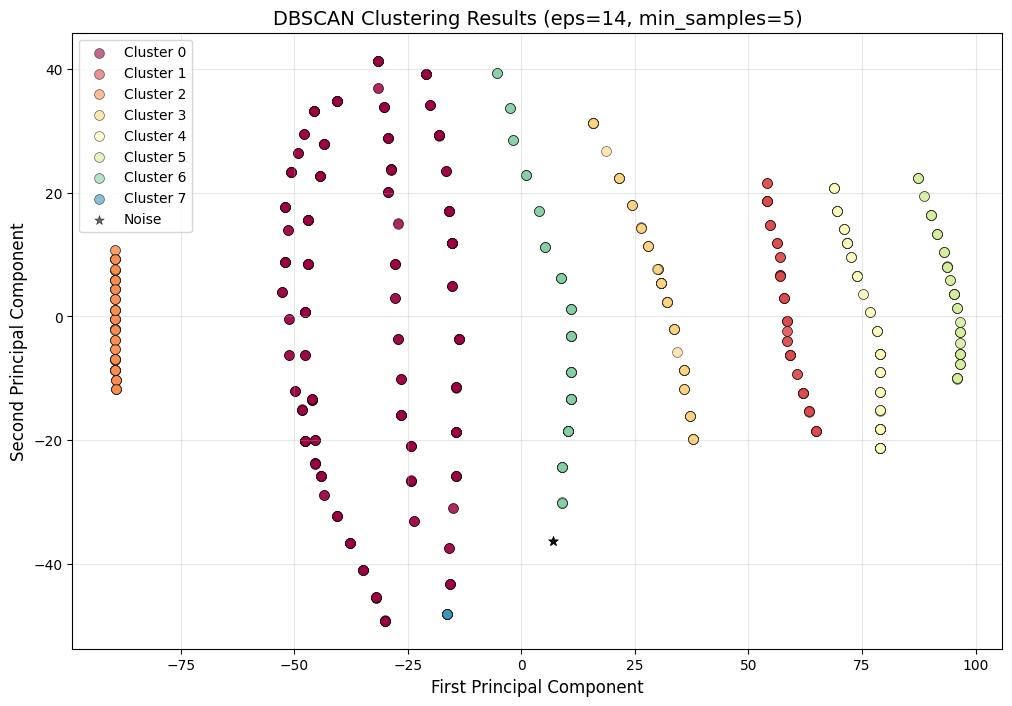

In [30]:
# DBSCAN 分群
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import numpy as np

# 測試不同的 eps 值，使用更大的範圍
eps_values = [10, 12, 14, 16, 18, 20]
print("=== 測試不同 eps 值的分群結果 ===\n")

for eps_val in eps_values:
    dbscan_test = DBSCAN(eps=eps_val, min_samples=5)
    dbscan_test.fit(X_train)
    n_clusters = len(set(dbscan_test.labels_)) - (1 if -1 in dbscan_test.labels_ else 0)
    n_noise = list(dbscan_test.labels_).count(-1)
    print(f"eps={eps_val}: {n_clusters} 群, {n_noise} 個噪音點")

# 使用 eps=14 以獲得約 5 群和少量噪音點
dbscan = DBSCAN(eps=14, min_samples=5)
dbscan.fit(X_train)

print("\n=== 最終 DBSCAN 分群結果 (eps=14, min_samples=5) ===")
print(f"分群結果：{dbscan.labels_}")
print("=================================")
print(f"各群樣本數：")
for label, count in zip(*np.unique(dbscan.labels_, return_counts=True)):
    if label == -1:
        print(f"噪音點: {count} 筆")
    else:
        print(f"群 {label}: {count} 筆")
        
n_clusters_final = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_noise = list(dbscan.labels_).count(-1)
print(f"\n總共分為 {n_clusters_final} 群，{n_noise} 個噪音點")

# 計算 Silhouette 係數（排除噪音點）
if len(set(dbscan.labels_)) > 1 and -1 not in dbscan.labels_:
    silhouette_avg = metrics.silhouette_score(X_train, dbscan.labels_)
    print(f"\nSilhouette 係數：{silhouette_avg:.4f}")
elif len([l for l in dbscan.labels_ if l != -1]) > 0:
    # 如果有噪音點，只計算非噪音點的 Silhouette 係數
    mask = dbscan.labels_ != -1
    if len(set(dbscan.labels_[mask])) > 1:
        silhouette_avg = metrics.silhouette_score(X_train[mask], dbscan.labels_[mask])
        print(f"\nSilhouette 係數（不含噪音點）：{silhouette_avg:.4f}")

# 使用 PCA 降維以視覺化
pca = PCA(n_components=2).fit(X_train)
pca_2d = pca.transform(X_train)

# 繪製分群結果
plt.figure(figsize=(12, 8))
unique_labels = set(dbscan.labels_)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    if label == -1:
        # 噪音點用黑色星號表示
        color = 'black'
        marker = '*'
        label_name = 'Noise'
    else:
        marker = 'o'
        label_name = f'Cluster {label}'
    
    mask = dbscan.labels_ == label
    plt.scatter(pca_2d[mask, 0], pca_2d[mask, 1], 
                c=[color], marker=marker, s=50, 
                label=label_name, alpha=0.6, edgecolors='k', linewidths=0.5)

plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title(f'DBSCAN Clustering Results (eps={dbscan.eps}, min_samples={dbscan.min_samples})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 分群結果比較與分析

=== 三種分群演算法比較 ===
         演算法  群數  Silhouette 係數  噪音點數
      KMeans   2       0.539019     0
Hierarchical   3       0.417281     0
      DBSCAN   8       0.272300     3


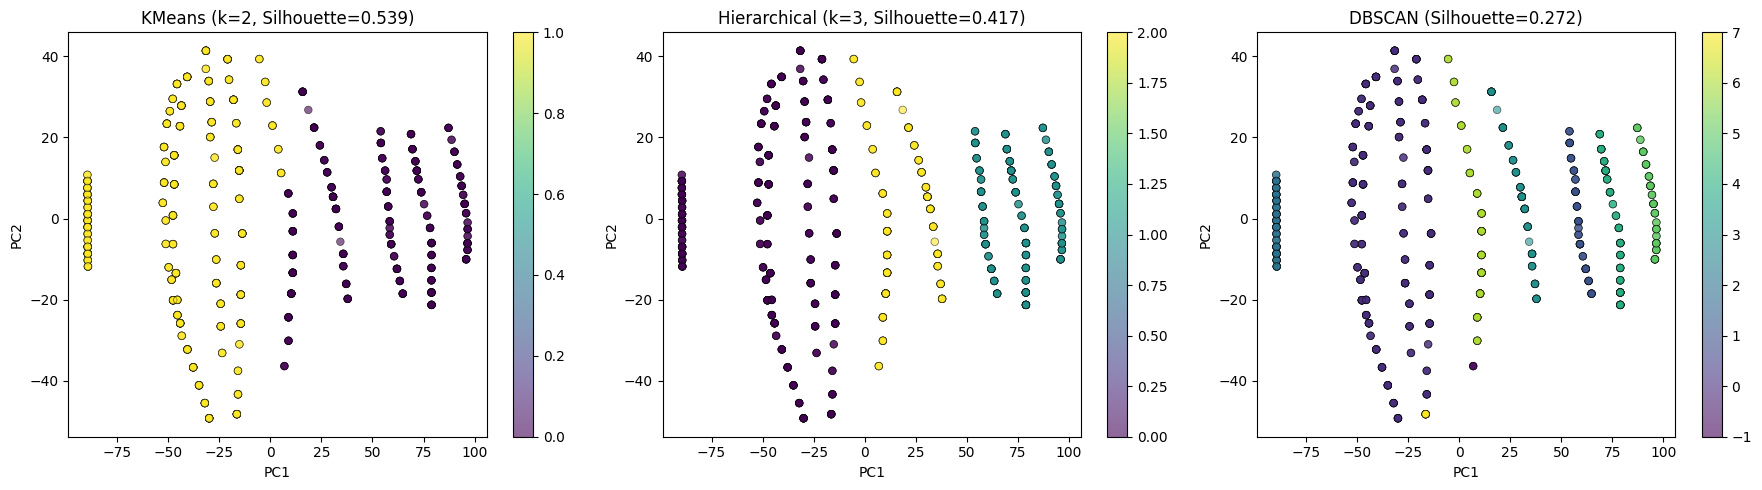

In [31]:
# 比較三種分群演算法的結果
import pandas as pd

# 使用最佳參數重新訓練各模型
kmeans_best = cluster.KMeans(n_clusters=best_k, random_state=100).fit(X_train)
hclust_model = cluster.AgglomerativeClustering(linkage='ward', n_clusters=3).fit(X_train)
dbscan_model = DBSCAN(eps=14, min_samples=5).fit(X_train)

# 計算各模型的 Silhouette 係數
kmeans_silhouette = metrics.silhouette_score(X_train, kmeans_best.labels_)
hclust_silhouette = metrics.silhouette_score(X_train, hclust_model.labels_)

# DBSCAN 的 Silhouette 係數（排除噪音點）
dbscan_mask = dbscan_model.labels_ != -1
if len(set(dbscan_model.labels_[dbscan_mask])) > 1:
    dbscan_silhouette = metrics.silhouette_score(X_train[dbscan_mask], dbscan_model.labels_[dbscan_mask])
else:
    dbscan_silhouette = 0

# 建立比較表格
comparison_df = pd.DataFrame({
    '演算法': ['KMeans', 'Hierarchical', 'DBSCAN'],
    '群數': [best_k, 3, len(set(dbscan_model.labels_)) - (1 if -1 in dbscan_model.labels_ else 0)],
    'Silhouette 係數': [kmeans_silhouette, hclust_silhouette, dbscan_silhouette],
    '噪音點數': [0, 0, sum(dbscan_model.labels_ == -1)]
})

print("=== 三種分群演算法比較 ===")
print(comparison_df.to_string(index=False))

# 繪製比較圖
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA 降維
pca = PCA(n_components=2).fit(X_train)
pca_2d = pca.transform(X_train)

# KMeans 結果
scatter1 = axes[0].scatter(pca_2d[:, 0], pca_2d[:, 1], c=kmeans_best.labels_, 
                           cmap='viridis', s=30, alpha=0.6, edgecolors='k', linewidths=0.5)
axes[0].set_title(f'KMeans (k={best_k}, Silhouette={kmeans_silhouette:.3f})', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

# Hierarchical Clustering 結果
scatter2 = axes[1].scatter(pca_2d[:, 0], pca_2d[:, 1], c=hclust_model.labels_, 
                           cmap='viridis', s=30, alpha=0.6, edgecolors='k', linewidths=0.5)
axes[1].set_title(f'Hierarchical (k=3, Silhouette={hclust_silhouette:.3f})', fontsize=12)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1])

# DBSCAN 結果
scatter3 = axes[2].scatter(pca_2d[:, 0], pca_2d[:, 1], c=dbscan_model.labels_, 
                           cmap='viridis', s=30, alpha=0.6, edgecolors='k', linewidths=0.5)
axes[2].set_title(f'DBSCAN (Silhouette={dbscan_silhouette:.3f})', fontsize=12)
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
plt.colorbar(scatter3, ax=axes[2])

plt.tight_layout()
plt.show()

=== 各分群演算法的 Health_Risk_Score 分佈分析 ===

1. KMeans 分群:
         count      mean       std       min       25%       50%       75%  \
Cluster                                                                      
0        347.0  0.445535  1.091681 -1.547193 -0.476482  0.379303  1.420877   
1        453.0 -0.391080  0.710389 -1.820272 -0.866574 -0.525486 -0.059996   

              max  
Cluster            
0        2.585593  
1        1.782938  

2. Hierarchical Clustering 分群:
         count      mean       std       min       25%       50%       75%  \
Cluster                                                                      
0        433.0 -0.386907  0.717925 -1.820272 -0.867715 -0.537939 -0.054629   
1        218.0  1.050167  0.852736 -0.939100  0.458370  1.269759  1.649867   
2        149.0 -0.563518  0.555127 -1.547193 -1.050680 -0.455556 -0.177729   

              max  
Cluster            
0        1.782938  
1        2.585593  
2        0.870665  

3. DBSCAN 分群:
         count 

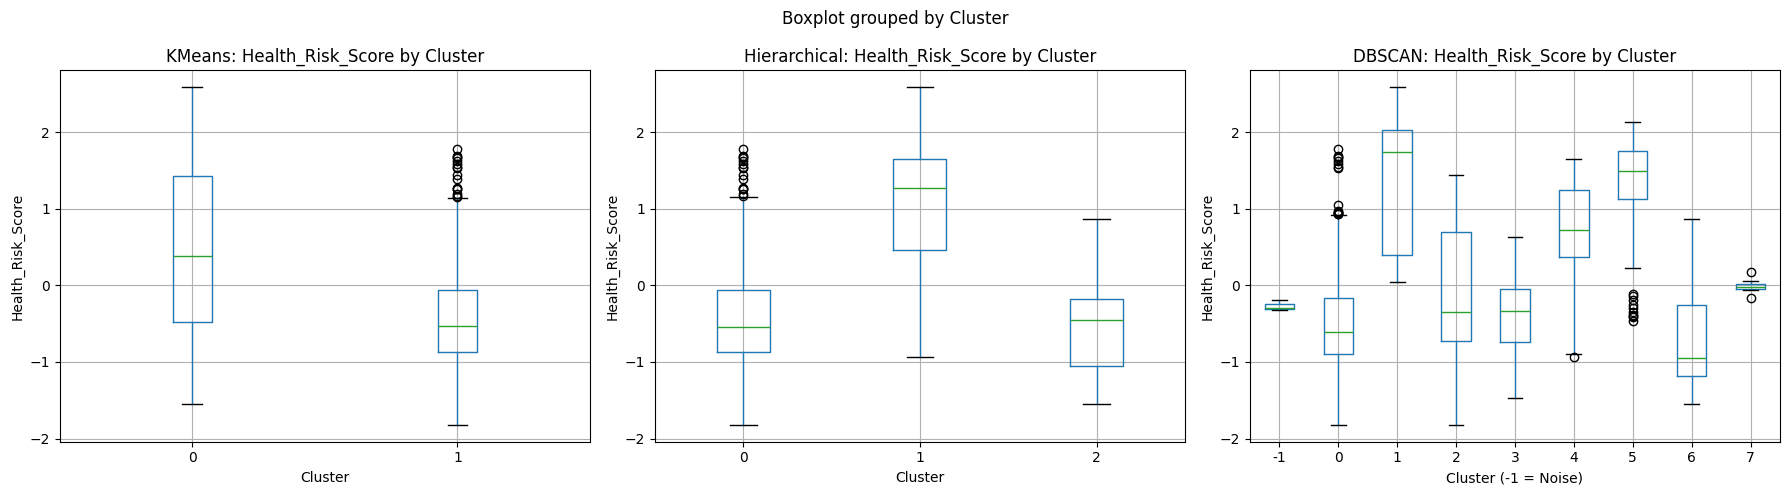

In [32]:
# 分析各群的 Health_Risk_Score 分佈
print("=== 各分群演算法的 Health_Risk_Score 分佈分析 ===\n")

# KMeans 分群的 Health_Risk_Score 分析
print("1. KMeans 分群:")
kmeans_cluster_df = pd.DataFrame({
    'Cluster': kmeans_best.labels_,
    'Health_Risk_Score': y_train.values
})
print(kmeans_cluster_df.groupby('Cluster')['Health_Risk_Score'].describe())

# Hierarchical Clustering 分群的 Health_Risk_Score 分析
print("\n2. Hierarchical Clustering 分群:")
hclust_cluster_df = pd.DataFrame({
    'Cluster': hclust_model.labels_,
    'Health_Risk_Score': y_train.values
})
print(hclust_cluster_df.groupby('Cluster')['Health_Risk_Score'].describe())

# DBSCAN 分群的 Health_Risk_Score 分析
print("\n3. DBSCAN 分群:")
dbscan_cluster_df = pd.DataFrame({
    'Cluster': dbscan_model.labels_,
    'Health_Risk_Score': y_train.values
})
cluster_stats = dbscan_cluster_df.groupby('Cluster')['Health_Risk_Score'].describe()
print(cluster_stats)

# 繪製各群的 Health_Risk_Score 分佈箱型圖
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KMeans 箱型圖
kmeans_cluster_df.boxplot(column='Health_Risk_Score', by='Cluster', ax=axes[0])
axes[0].set_title('KMeans: Health_Risk_Score by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Health_Risk_Score')

# Hierarchical 箱型圖
hclust_cluster_df.boxplot(column='Health_Risk_Score', by='Cluster', ax=axes[1])
axes[1].set_title('Hierarchical: Health_Risk_Score by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Health_Risk_Score')

# DBSCAN 箱型圖
dbscan_cluster_df.boxplot(column='Health_Risk_Score', by='Cluster', ax=axes[2])
axes[2].set_title('DBSCAN: Health_Risk_Score by Cluster')
axes[2].set_xlabel('Cluster (-1 = Noise)')
axes[2].set_ylabel('Health_Risk_Score')

plt.tight_layout()
plt.show()